c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training samples: 17065
Validation samples: 2485
Test samples: 4830

Training category counts:
Casualties : 5110
Infrastructure Damage : 5715
Rescue Request : 1833
Not Relevant : 4407

TF-IDF shapes:
Training: (17065, 10000)
Validation: (2485, 10000)
Test: (4830, 10000)

Model training completed!

Validation Accuracy: 0.8925553319919517

Validation Classification Report:
                       precision    recall  f1-score   support

           Casualties       0.96      0.92      0.94       746
Infrastructure Damage       0.92      0.90      0.91       831
         Not Relevant       0.82      0.86      0.84       644
       Rescue Request       0.82      0.88      0.84       264

             accuracy                           0.89      2485
            macro avg       0.88      0.89      0.88      2485
         weighted avg       0.90      0.89      0.89      2485


FINAL TEST RESULTS

Test Accuracy: 0.8987577639751553

Test Classification Report:
                       precision   

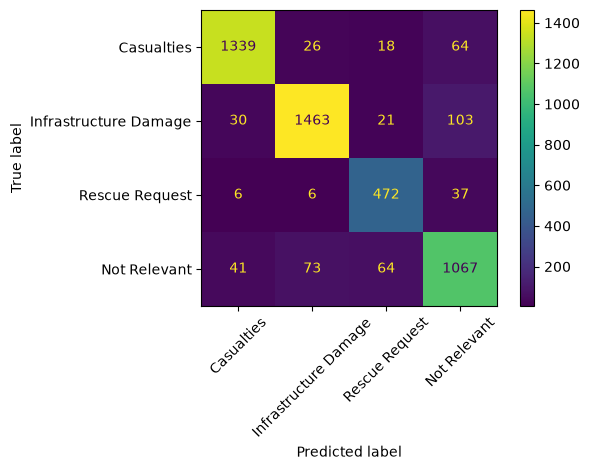


Model and vectorizer saved successfully!


In [1]:
from datasets import load_dataset
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib


# ==========================================
# 1. LOAD HUM-AID DATASET
# ==========================================

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/test-00000-of-00001.parquet"
    }
)


# ==========================================
# 2. SELECT FOUR TARGET CATEGORIES
# ==========================================

mapping = {
    "injured_or_dead_people": "Casualties",
    "infrastructure_and_utility_damage": "Infrastructure Damage",
    "requests_or_urgent_needs": "Rescue Request",
    "not_humanitarian": "Not Relevant"
}


def prepare_data(split):
    data = []

    for row in dataset[split]:

        original_label = row["class_label"]

        if original_label in mapping:
            data.append({
                "text": row["tweet_text"],
                "label": mapping[original_label]
            })

    return data


train_data = prepare_data("train")
validation_data = prepare_data("validation")
test_data = prepare_data("test")


print("Training samples:", len(train_data))
print("Validation samples:", len(validation_data))
print("Test samples:", len(test_data))


print("\nTraining category counts:")

counts = Counter(row["label"] for row in train_data)

for label, count in counts.items():
    print(label, ":", count)


# ==========================================
# 3. SEPARATE TEXT AND LABELS
# ==========================================

X_train_text = [row["text"] for row in train_data]
y_train = [row["label"] for row in train_data]

X_validation_text = [row["text"] for row in validation_data]
y_validation = [row["label"] for row in validation_data]

X_test_text = [row["text"] for row in test_data]
y_test = [row["label"] for row in test_data]


# ==========================================
# 4. TF-IDF FEATURE EXTRACTION
# ==========================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

# Learn vocabulary only from training data
X_train = vectorizer.fit_transform(X_train_text)

# Use the same vocabulary for validation and test
X_validation = vectorizer.transform(X_validation_text)
X_test = vectorizer.transform(X_test_text)


print("\nTF-IDF shapes:")
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)


# ==========================================
# 5. TRAIN LOGISTIC REGRESSION MODEL
# ==========================================

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("\nModel training completed!")


# ==========================================
# 6. VALIDATION EVALUATION
# ==========================================

y_validation_pred = model.predict(X_validation)

validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

print("\nValidation Accuracy:", validation_accuracy)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_validation,
        y_validation_pred
    )
)


# ==========================================
# 7. FINAL TEST EVALUATION
# ==========================================

y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("\nTest Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred
    )
)


# ==========================================
# 8. FINAL TEST CONFUSION MATRIX
# ==========================================

labels = [
    "Casualties",
    "Infrastructure Damage",
    "Rescue Request",
    "Not Relevant"
]

test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels
)

print("\nFinal Test Confusion Matrix:") 
print(test_cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=labels
)

disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()


# ==========================================
# 9. SAVE MODEL AND VECTORIZER
# ==========================================

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("\nModel and vectorizer saved successfully!")